# TensorBoard Analysis and Model Convergence

## Objective
This notebook is dedicated to analysing training and evaluation metrics using
TensorBoard. Model convergence is assessed using the loss curves and
mean Average Precision (mAP) at Intersection over Union (IoU) thresholds of 0.5 and 0.75, in line with the
coursework specification.

The purpose of this notebook is to justify the number of training steps used
and determine whether further training would lead to meaningful performance
improvements.


## Launching TensorBoard

TensorBoard is launched to visualise both training and evaluation metrics.
Particular attention is paid to:

- Training loss to assess optimisation behaviour
- mAP at Intersection over Union (IoU) thresholds of 0.5 and 0.75 to assess
  localisation accuracy

These metrics are used together to determine whether the model has converged.

In [6]:
import os

PATH_TO_MODEL = "./training/TF2/training/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8"

In [14]:
#Run Tensorboard
# Run through Terminal if this code stalls (tensorboard --logdir=training/TF2/training)
!tensorboard --logdir=training/TF2/training

^C


In [15]:
#Load in-window tensorboard view
#Fiter by 'loss' for classification and Localization graphs
#Click Scalars to view IoU information

%reload_ext tensorboard
%tensorboard --logdir {PATH_TO_MODEL}

Reusing TensorBoard on port 6006 (pid 23160), started 11:37:43 ago. (Use '!kill 23160' to kill it.)

## Training Convergence Analysis

Model convergence was assessed by examining training loss trends over the training duration.

A clear downward trend in training loss followed by stabilisation was observed, indicating that the model had sufficiently learned meaningful feature representations without signs of divergence or instability.

Screenshots for each have been provided for each subheading for clarity, however the tensorboard is still available for an in-depth analysis

## Loss Analysis

The following loss metrics were examined to assess model learning behaviour and convergence. Due to the inherent variability in object detection training, emphasis is placed on long-term trends rather than individual batch-level fluctuations.


### Total Loss

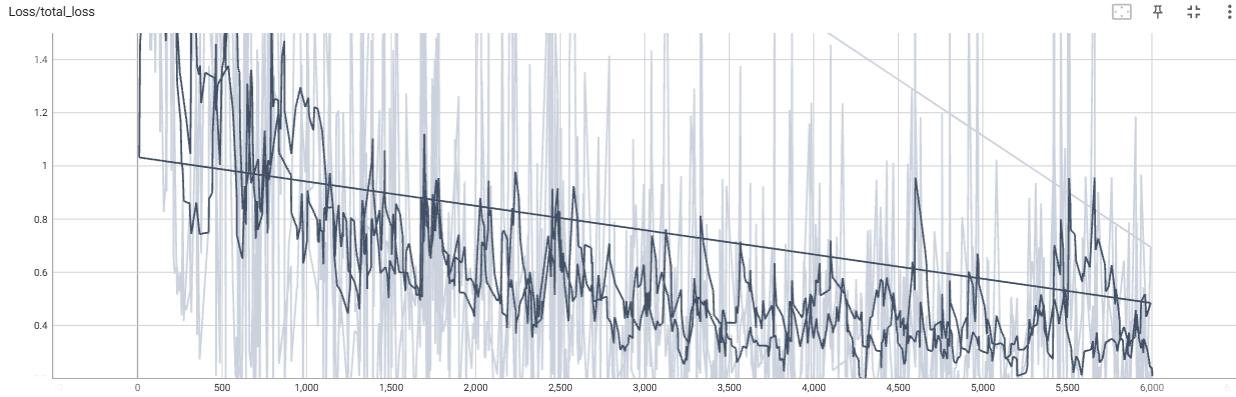

The total training loss shows a clear downward trend over the course of training, indicating that the Faster R-CNN model is progressively learning more accurate region proposals and object classifications. Although the loss exhibits noticeable short-term fluctuations, this behaviour is expected due to the stochastic nature of mini-batch optimisation and the complexity of the two-stage Faster R-CNN architecture.

Despite this variability, the smoothed loss curve demonstrates a consistent reduction from the initial training steps to the final iteration, suggesting stable optimisation and successful convergence. No signs of divergence or instability are observed, indicating that the learning rate schedule and optimisation parameters were appropriately configured.

Rapid, short-term spikes in loss are observed and are expected due to batch-level variation and the two-stage optimisation process of Faster R-CNN. The smoothed trend confirms stable convergence despite this variability.



### Classification Loss Behaviour


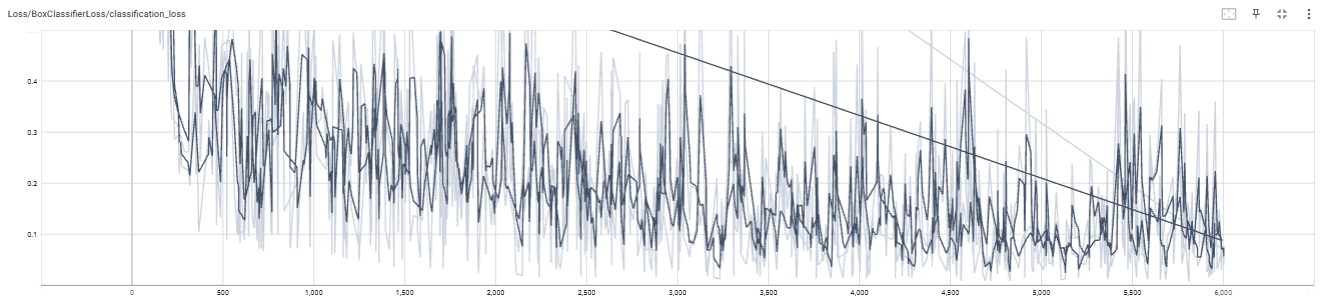

The classification loss demonstrates substantial short-term variability, which is expected in batch-level object detection training due to differences in image complexity and object count across batches.

When viewed with moderate TensorBoard smoothing, an overall downward trend is observable throughout training, indicating progressive improvement in the model’s ability to correctly classify target objects.


In later training stages, improvements in classification loss become marginal, suggesting that the model has largely learned stable classification representations.


#### Late-Stage Loss Variability

Although the classification loss exhibits occasional spikes in later training stages, the overall loss baseline remains low and stable.

These spikes are attributable to batch-level variability in object detection training, where certain images present greater classification difficulty due to factors such as occlusion, background complexity, or object scale. The presence of such variability indicates continued exposure to challenging samples rather than training instability.

Importantly, the absence of a rising loss baseline or increasing spike magnitude suggests that the model remains stable and has not diverged. Instead, the observed behaviour is consistent with a model that has largely converged while continuing to refine its predictions on harder examples.



### Localization Loss Behaviour


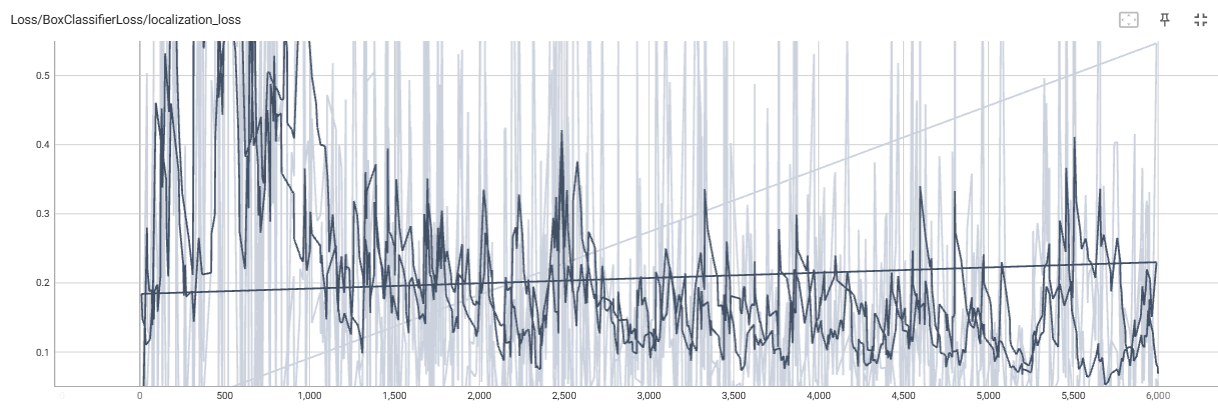

The localisation loss exhibits high variability throughout training, which is expected for bounding box regression tasks where small spatial misalignments can produce large loss values.

Unlike classification loss, localisation loss does not necessarily decrease monotonically. Instead, it oscillates around a stable range as the model continues to refine bounding box predictions across varying object scales and scene complexities.


Occasional spikes in localisation loss are observed in later training stages. These are attributable to challenging samples involving occlusion, small objects, or partial visibility, which increase the difficulty of precise bounding box alignment.

Importantly, the absence of an increasing loss baseline suggests that the model remains stable and that these spikes do not indicate divergence.

While localisation loss provides insight into bounding box regression behaviour, final localisation performance is more reliably assessed using mAP at IoU thresholds of 0.50 and 0.75, which is examined in the following section.



## Learning Rate

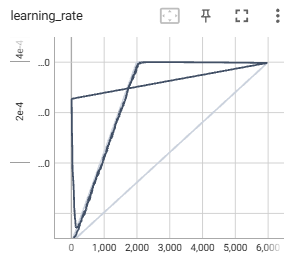

The learning rate schedule used during training is shown to provide additional context for the model’s optimisation behaviour. An initial warm-up phase is applied, where the learning rate starts near zero and rises linearly to approximately 4e-4 over roughly the first 2,000 steps. This helps stabilise Faster R-CNN training and prevents large gradient updates before the network weights have adapted from the pre-trained COCO checkpoint.

After the warm-up period, the learning rate stays constant at this value for the remainder of training, up to step 6,000. This schedule supports stable convergence and complements the observed reduction in training loss.


## IoU-based Convergence Evidence

Evaluation mAP at IoU thresholds of 0.50 and 0.75 is recorded at the final
training checkpoint. Due to the evaluation configuration used during training,
these metrics are logged only at the final step rather than at regular intervals.

As a result, convergence is primarily assessed using the stabilisation of
the training loss curves. The final mAP values at IoU 0.50 and 0.75
provide confirmation that the model achieved acceptable localisation quality
at the selected stopping point.

Taken together, loss convergence and final evaluation mAP are used to justify
terminating training at 6000 steps.


### mAP Summary

> **Note:** the mAP screenshots below are from an evaluation logged on Mon 5 Jan at step 6,000. The most recent evaluation event file listed in notebook 03 was written later, on 8 Jan 2026 (22:35–23:39 UTC), so these screenshots come from an earlier evaluation run.


#### mAP @ 0.50 IoU 

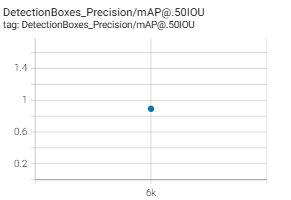 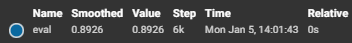

#### mAP @ 0.75 IoU 

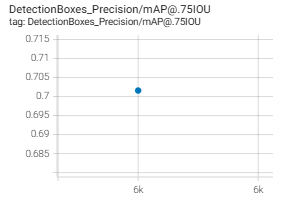 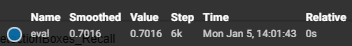

## Convergence and Stopping Point Justification


Training was stopped at 6000 steps, as the training loss had stabilised and no
further meaningful improvements were observed. The final mAP values at
IoU thresholds 0.50 and 0.75 (0.8926 and 0.7016), recorded at the last evaluation step, confirm that
this was an appropriate point to stop training, especially with only 500 annotated images per class, about 90% of which were used for training.
